# Embedding generation
---
1. Knowledge graph generation
2. Edges train-validation-test split
3. Node embeddings generation on training edges with node2vec
4. Edge embeddings generation by taking the Hadamard product of node embeddings
5. Cross-validation by link prediction task on validation and test edges with loggistic regression
6. Node embeddings generation with tuned hyper-parameters on all edges with node2vec

## 1. Knowledge graph generation
---
hpo ontology
https://raw.githubusercontent.com/obophenotype/human-phenotype-ontology/master/hp.obo

gene-phenotype annotations
http://compbio.charite.de/jenkins/job/hpo.annotations/lastSuccessfulBuild/artifact/util/annotation/genes_to_phenotype.txt


In [1]:
import os
import pandas as pd
from CADA.triples_gene_hpo import triples_gene_hpo
from CADA.triples_patients import triples_patients
from CADA.triples_hierarchical_hpo import triples_hierarchical_hpo
from CADA.split import split

In [2]:
# get a list of triple of nodes and relationships between them
triples = []

hpo_triples = triples_hierarchical_hpo() # triples of hpo-hpo hierarchical relationships from hpo ontology
gene_hpo_triples = triples_gene_hpo() # triples of gene-hpo relationships from hpo gene-hpo annotation file

train_size = 0
node_gene = True
node_disease = False
# train, test = split(train_size, os.getcwd()) # from sklearn.model_selection import train_test_split
# train_patients_triples = triples_patients(node_gene, node_disease, train) # triples of patient-gene, patient-hpo relationships from case annotations


triples += hpo_triples
triples += gene_hpo_triples
# triples += train_patients_triples


c:\users\burit\documents\github\cada\src\CADA\triples_hierarchical_hpo.py:13: UnicodeWarning: unsound encoding, assuming ISO-8859-1 (73% confidence)
  hpo = pronto.Ontology(os.path.join(DATA_DIRECTORY, 'raw', 'hpo', 'hpo_hierarchical_information', 'hp.obo'))


In [3]:
# save triples
all_triples = pd.DataFrame(triples)
all_triples.to_csv('results/all.triples', header=None, index=False, sep='\t')


In [4]:
import networkx as nx

In [5]:
# Generate graph from triples
edges = []
links = []
for triple in triples:
    links.append(triple[1])
    edges.append((triple[0], triple[2]))
g = nx.Graph()
g.add_edges_from(edges)
nodes = list(g.nodes)
nodes_hpo = nodes_gene = nodes_disease = nodes_patient = 0
for node in nodes:
    if node.startswith("HP:"):
        nodes_hpo += 1
    elif node.startswith("Entrez:"):
        nodes_gene += 1
    elif node.startswith("OMIM:"):
        nodes_disease += 1
    elif node.startswith("Patient:"):
        nodes_patient += 1

nx.write_graphml(g, 'results/gene-hpo.graphml')

In [6]:
from operator import itemgetter
# Inspect graph
adj_sparse = nx.to_scipy_sparse_matrix(g)
is_a = links.count('is_a')
is_feature_of_mutation = links.count('is_feature_of_mutation')
print("Total nodes:", adj_sparse.shape[0])
print("Total edges:", int(adj_sparse.nnz/2)) # adj is symmetric, so nnz (num non-zero) = 2*num_edges
print(f'Number of nodes of hpo terms: {nodes_hpo}')
print(f'Number of nodes of genes: {nodes_gene}')
print(f'Number of nodes of disease: {nodes_disease}')
print(f'Number of nodes of patient: {nodes_patient}')
print(f'Number of edges of hpo hierarchical relationships: {is_a}')
print(f'Number of edges of gene-hpo annotations: {is_feature_of_mutation}')



Total nodes: 19280
Total edges: 188230
Number of nodes of hpo terms: 14965
Number of nodes of genes: 4315
Number of nodes of disease: 0
Number of nodes of patient: 0
Number of edges of hpo hierarchical relationships: 18949
Number of edges of gene-hpo annotations: 205428


## 2. Edges train-validation-test split

In [7]:
import numpy as np
from CADA.gae.preprocessing import mask_test_edges

In [8]:
# Perform edges train-validation-test split
np.random.seed(0)
adj_train, train_edges, train_edges_false, val_edges, val_edges_false, \
    test_edges, test_edges_false = mask_test_edges(adj_sparse, test_frac=.1, val_frac=.1, prevent_disconnect=False, verbose=True)
g_train = nx.from_scipy_sparse_matrix(adj_train) # new graph object with only non-hidden edges


preprocessing...
generating test/val sets...
creating false test edges...
creating false val edges...
creating false train edges...
final checks for disjointness...
creating adj_train...
Done with train-test split!



In [9]:
# Inspect train/test split
print(f'Number of nodes: {g.number_of_nodes()}')
print(f'Number of edges: {g.number_of_edges()}')
print(f'Training edges (positive): {len(train_edges)}')
print(f'Training edges (negative): {len(train_edges_false)}')
print(f'Validation edges (positive): {len(val_edges)}')
print(f'Validation edges (negative): {len(val_edges_false)}')
print(f'Test edges (positive): {len(test_edges)}')
print(f'Test edges (negative): {len(test_edges_false)}')

Number of nodes: 19280
Number of edges: 188230
Training edges (positive): 150584
Training edges (negative): 150584
Validation edges (positive): 18823
Validation edges (negative): 18823
Test edges (positive): 18823
Test edges (negative): 18823


## 3. Node embeddings generation on training edges with node2vec

In [10]:
from node2vec import Node2Vec
# node2vec settings
# NOTE: When p = q = 1, this is equivalent to DeepWalk
dimensions = 128
walk_length = 30 # Length of walk per source
num_walks = 10 # Number of walks per source
window = 5 # Window size
workers = 1 # Num. parallel workers
p = 1 # Return hyperparameter
q = 1 # In-out hyperparameter


In [11]:
# Generate walks and train node2vec model on training edges
node2vec = Node2Vec(g_train, dimensions=dimensions, walk_length=walk_length, num_walks=num_walks, workers=workers, p=p, q=q)
model = node2vec.fit(window=window, min_count=1, batch_words=4)

Generating walks (CPU: 1): 100%|██████████| 10/10 [05:17<00:00, 31.71s/it]


In [12]:
# get embeddings and create node embeddings matrix(rows = nodes, columns = embedding features)
emb_mappings = model.wv
emb_list = []
for node_index in range(0, adj_sparse.shape[0]):
    node_str = str(node_index)
    node_emb = emb_mappings[node_str]
    emb_list.append(node_emb)
emb_matrix = np.vstack(emb_list)

## 4. Edge embeddings by taking the Hadamard product of node embeddings

In [13]:
# Generate bootstrapped edge embeddings (as is done in node2vec paper)
# Edge embedding for (v1, v2) = hadamard product of node embeddings for v1, v2
def get_edge_embeddings(edge_list):
    embs = []
    for edge in edge_list:
        node1 = edge[0]
        node2 = edge[1]
        emb1 = emb_matrix[node1]
        emb2 = emb_matrix[node2]
        edge_emb = np.multiply(emb1, emb2)
        embs.append(edge_emb)
    embs = np.array(embs)
    return embs

In [14]:
# Train-set edge embeddings, labels: 1 = real edge, 0 = false edge
pos_train_edge_embs = get_edge_embeddings(train_edges)
neg_train_edge_embs = get_edge_embeddings(train_edges_false)
train_edge_embs = np.concatenate([pos_train_edge_embs, neg_train_edge_embs])
train_edge_labels = np.concatenate([np.ones(len(train_edges)), np.zeros(len(train_edges_false))])

# Val-set edge embeddings, labels: 1 = real edge, 0 = false edge
pos_val_edge_embs = get_edge_embeddings(val_edges)
neg_val_edge_embs = get_edge_embeddings(val_edges_false)
val_edge_embs = np.concatenate([pos_val_edge_embs, neg_val_edge_embs])
val_edge_labels = np.concatenate([np.ones(len(val_edges)), np.zeros(len(val_edges_false))])

# Test-set edge embeddings, labels: 1 = real edge, 0 = false edge
pos_test_edge_embs = get_edge_embeddings(test_edges)
neg_test_edge_embs = get_edge_embeddings(test_edges_false)
test_edge_embs = np.concatenate([pos_test_edge_embs, neg_test_edge_embs])
test_edge_labels = np.concatenate([np.ones(len(test_edges)), np.zeros(len(test_edges_false))])

## 5. Cross-validation by link prediction task on validation and test edges with loggistic regression

In [15]:
# Train logistic regression classifier on train-set edge embeddings
from sklearn.linear_model import LogisticRegression
edge_classifier = LogisticRegression(random_state=0)
edge_classifier.fit(train_edge_embs, train_edge_labels)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=0, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [16]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score, average_precision_score

In [17]:
# Predicted edge scores: probability of being of class "1" (real edge)
val_preds = edge_classifier.predict_proba(val_edge_embs)[:, 1]
val_roc = roc_auc_score(val_edge_labels, val_preds)
val_ap = average_precision_score(val_edge_labels, val_preds)

test_preds = edge_classifier.predict_proba(test_edge_embs)[:, 1]
test_roc = roc_auc_score(test_edge_labels, test_preds)
test_ap = average_precision_score(test_edge_labels, test_preds)

print(f'node2vec Validation ROC score: {val_roc:.2f}')
print(f'node2vec Validation AP score: {val_ap:.2f}')
print(f'node2vec Test ROC score: {test_roc:.2f}')
print(f'node2vec Test AP score: {test_ap:.2f}')

node2vec Validation ROC score: 0.92
node2vec Validation AP score: 0.94
node2vec Test ROC score: 0.92
node2vec Test AP score: 0.95


In [19]:
from matplotlib import pyplot as plt

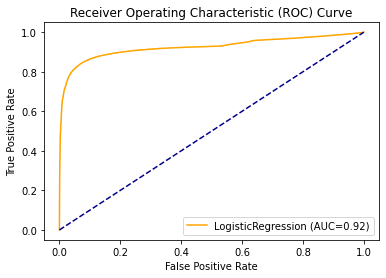

In [20]:
# calculate and draw roc curve
fper, tper, thresholds = roc_curve(test_edge_labels, test_preds) 
plt.figure()
plt.plot(fper, tper, color='orange', label=f'LogisticRegression (AUC={test_roc:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.savefig("figures/roc_curve.png")

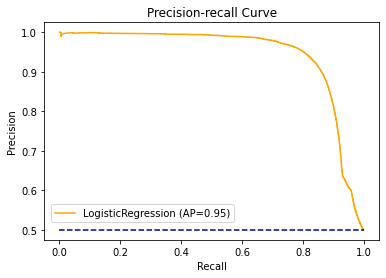

In [21]:
# calculate and draw precision-recall curve
precision, recall, thresholds = precision_recall_curve(test_edge_labels, test_preds) 
area_pr = auc(recall, precision)
no_skill = len(test_edge_labels[test_edge_labels==1]) / len(test_edge_labels)
plt.figure()
plt.plot(recall, precision, color='orange', label=f'LogisticRegression (AP={area_pr:.2f})')
ax = plt.gca()
ax.legend(loc=(0.02, 0.08))
plt.plot([0, 1], [no_skill, no_skill], color='darkblue', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-recall Curve')
plt.savefig("figures/pr_curve.png")

#### 6. Node embeddings generation with tuned hyper-parameters on all edges with node2vec

In [22]:
# Generate walks and train node2vec model on all edges
node2vec = Node2Vec(g, dimensions=dimensions, walk_length=walk_length, num_walks=num_walks, workers=workers, p=p, q=q)
model = node2vec.fit(window=window, min_count=1, batch_words=4)
model.save('results/node2vec.model')
model.wv.save_word2vec_format('results/node2vec.embeddings')

Generating walks (CPU: 1): 100%|██████████| 10/10 [07:34<00:00, 45.46s/it]
